STEP 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, r2_score


STEP 2: Load Dataset (Fix Encoding)

In [3]:
df = pd.read_csv("player_stats.csv", encoding='latin1')
df.head()

,player,country,height,weight,age,club,ball_control,dribbling,marking,slide_tackle,...,curve,fk_acc,penalties,volleys,gk_positioning,gk_diving,gk_handling,gk_kicking,gk_reflexes,value
0,Cristian Castro Devenish,Colombia,192,84,22,Atl. Nacional,55,43,NaN,68,...,32,34,41,33,10,11,6,7,9,$1.400.000
1,Silaldo Taffarel,Brazil,181,80,31,Corinthians,69,70,NaN,56,...,65,62,48,46,12,15,14,8,14,$975.00
2,Thomas DÃ¤hne,Germany,193,84,29,Holstein Kiel,25,12,NaN,13,...,20,15,26,16,64,74,65,68,74,$1.100.000
3,Michael Sollbauer,Austria,187,86,33,SK Rapid Wien,46,48,NaN,66,...,25,13,22,19,10,10,8,14,9,$650.00
4,Diego Segovia,Uruguay,191,80,23,Independiente,14,8,NaN,14,...,9,10,16,5,61,59,62,64,64,$300.00


STEP 3: Clean Target Column (value)

In [4]:
def clean_value(x):
    x = str(x).strip()
    x = x.replace('$', '')

    # Handle European format like 1.400.000
    if x.count('.') > 1:
        x = x.replace('.', '')

    return float(x)

df['value'] = df['value'].apply(clean_value)

# Verify
print(df['value'].head())
print(df['value'].dtype)  # MUST be float64

0    1400000.0
1        975.0
2    1100000.0
3        650.0
4        300.0
Name: value, dtype: float64
float64


STEP 4: Handle Missing Values

In [5]:
df.fillna(0, inplace=True)

STEP 5: Drop Irrelevant Columns

In [6]:
df.drop(['player', 'club'], axis=1, inplace=True, errors='ignore')

STEP 6: Define Features & Target

In [7]:
X = df.drop('value', axis=1)
y = df['value']

STEP 7: Encode Categorical Variables

In [8]:
X = pd.get_dummies(X, drop_first=True)

STEP 8: Train-Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

STEP 9: Scaling

In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

STEP 10: FINAL CHECK (IMPORTANT)

In [11]:
print(y_train.dtype)  # must be float64
print(np.isnan(X_train_scaled).sum())  # must be 0

float64
0


STEP 11: Baseline Model (Linear Regression)

In [12]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

STEP 12: Evaluate

In [13]:
print("Linear Regression Results:")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2 Score:", r2_score(y_test, y_pred_lr))

Linear Regression Results:
RMSE: 6680203.9109008545
R2 Score: 0.252103195915506


STEP 13: PCA (Dimensionality Reduction)

In [15]:
# Ensure no NaN
X_train_scaled = np.nan_to_num(X_train_scaled)
X_test_scaled = np.nan_to_num(X_test_scaled)

pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Original shape:", X_train_scaled.shape)
print("Reduced shape:", X_train_pca.shape)

Original shape: (4545, 171)
Reduced shape: (4545, 130)


STEP 14: Model with PCA

In [16]:
lr_pca = LinearRegression()
lr_pca.fit(X_train_pca, y_train)

y_pred_pca = lr_pca.predict(X_test_pca)

print("PCA Model Results:")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_pca)))
print("R2 Score:", r2_score(y_test, y_pred_pca))

PCA Model Results:
RMSE: 7037887.322472144
R2 Score: 0.1698685693342411


STEP 15: Advanced Model (Random Forest)

In [17]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Results:")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2 Score:", r2_score(y_test, y_pred_rf))

Random Forest Results:
RMSE: 2274375.198686998
R2 Score: 0.9133065152281424


STEP 16: Hyperparameter Tuning

In [18]:
params = {
    'n_estimators': [100, 200],
    'max_depth': [10, None]
}

grid = GridSearchCV(RandomForestRegressor(), params, cv=3)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

y_pred_tuned = best_model.predict(X_test)

print("Tuned Model Results:")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_tuned)))
print("R2 Score:", r2_score(y_test, y_pred_tuned))

Tuned Model Results:
RMSE: 2205914.1276574424
R2 Score: 0.9184470936439064


STEP 17: Visualization

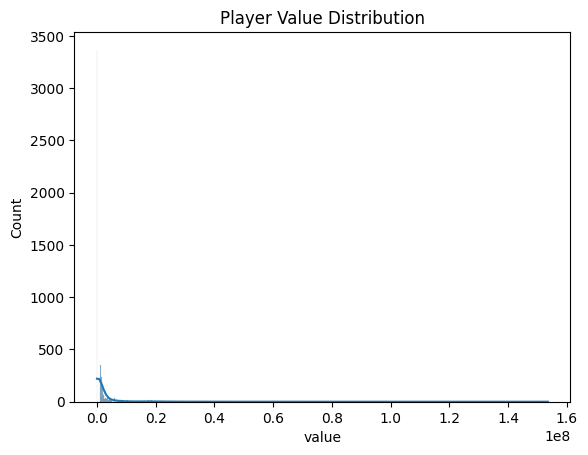

In [19]:
sns.histplot(y, kde=True)
plt.title("Player Value Distribution")
plt.show()

The player value distribution is highly skewed with the presence of outliers.

Most players have low values, while a few elite players dominate the high-value range.

This influenced the choice of models and preprocessing techniques.